In [ ]:
import numpy as np
import pandas as pd
import random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense,BatchNormalization, Flatten, MaxPool2D
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from keras.layers import Conv2D, Reshape
from tensorflow.keras.utils import Sequence
from keras.backend import epsilon
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import cv2

from sklearn.metrics import classification_report, confusion_matrix

import os

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image_dataset_from_directory

# 다운 받은 데이터 path를 만들어 두고요,
PATH = os.path.join(os.getcwd(), '/content/drive/MyDrive/최강<포빅아A4>/AI프로젝트/2인탑승/data')

# train과 validation 폴더 이름도 정해주고요.
train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# image_dataset_from_directory를 이용하면 batch size와 image size에 맞춰서 자동으로 나눠줍니다. 단, tf2.3이상이어야 되는 것 같아요.
# Batch size는 32, Image Size는 160x160입니다.
BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = image_dataset_from_directory(train_dir,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE)

validation_dataset = image_dataset_from_directory(validation_dir,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE)
test_dataset = image_dataset_from_directory(test_dir,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE)


Found 312 files belonging to 2 classes.
Found 50 files belonging to 2 classes.
Found 37 files belonging to 2 classes.


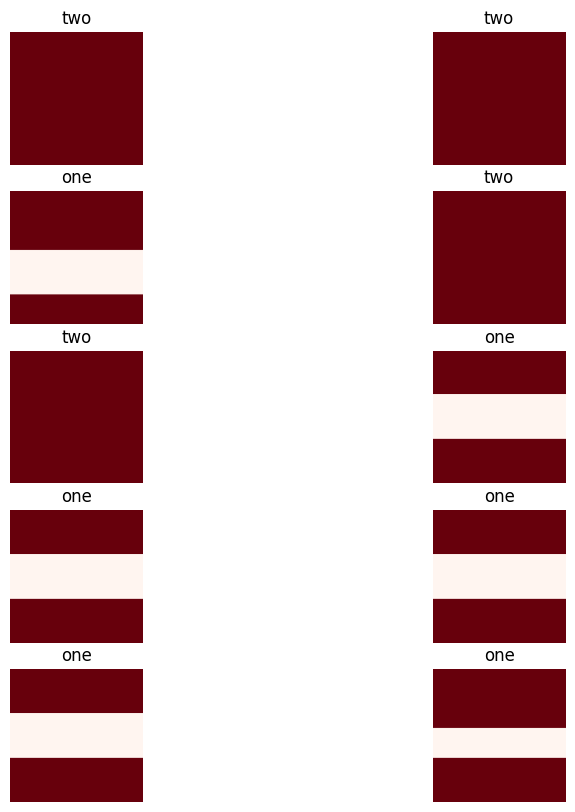

In [ ]:
plt.figure(figsize=(10, 10))
class_names = train_dataset.class_names
for images, labels in train_dataset.take(1): # 이렇게 하면 single batch를 가져올 수 있습니다.
    for i in range(10): # 32개이지만, 그냥 30개만 봐요.
        ax = plt.subplot(5, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [ ]:
layer_augmentation = tf.keras.Sequential([
  tf.keras.layers.experimental.preprocessing.RandomFlip('horizontal'),
  tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
])

In [ ]:
layer_monet_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [ ]:
layer_rescale = tf.keras.layers.experimental.preprocessing.Rescaling(1./127.5, offset= -1)

In [ ]:
IMG_SHAPE = (160 , 160 , 3)
model_base = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 [==============================] - 0s 0us/step


In [ ]:
model_base.trainable = False
image_batch, label_batch = next(iter(train_dataset))
output_batch = model_base(image_batch)
print(output_batch.shape)

(32, 5, 5, 1280)


In [ ]:
layer_global_average = tf.keras.layers.GlobalAveragePooling2D()
output_batch_average = layer_global_average(output_batch)
print(output_batch_average.shape)

(32, 1280)


In [ ]:
layer_out_fully_connected = tf.keras.layers.Dense(1)
prediction_on_batch_out = layer_out_fully_connected(output_batch_average)
print(prediction_on_batch_out.shape)

(32, 1)


In [ ]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = layer_augmentation(inputs)
x = layer_monet_input(x)
x = model_base(x)
x = layer_global_average(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = layer_out_fully_connected(x)
model = tf.keras.Model(inputs, outputs)

In [ ]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
first_step_epochs = 10
history = model.fit(train_dataset,
                    epochs=first_step_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
10/10 [==============================] - 22s 2s/step - loss: 1.1408 - accuracy: 0.4615 - val_loss: 0.4764 - val_accuracy: 0.7800
Epoch 2/10
10/10 [==============================] - 1s 57ms/step - loss: 0.9519 - accuracy: 0.5385 - val_loss: 0.4356 - val_accuracy: 0.7800
Epoch 3/10
10/10 [==============================] - 1s 54ms/step - loss: 0.7787 - accuracy: 0.6218 - val_loss: 0.4020 - val_accuracy: 0.7800
Epoch 4/10
10/10 [==============================] - 1s 54ms/step - loss: 0.6040 - accuracy: 0.7436 - val_loss: 0.3750 - val_accuracy: 0.7800
Epoch 5/10
10/10 [==============================] - 1s 68ms/step - loss: 0.5339 - accuracy: 0.8397 - val_loss: 0.3531 - val_accuracy: 0.9400
Epoch 6/10
10/10 [==============================] - 1s 52ms/step - loss: 0.4600 - accuracy: 0.8814 - val_loss: 0.3339 - val_accuracy: 0.9800
Epoch 7/10
10/10 [==============================] - 1s 54ms/step - loss: 0.3636 - accuracy: 0.9647 - val_loss: 0.3171 - val_accuracy: 1.0000
Epoch 8/10
10/

In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)
print(test_dataset)

2/2 [==============================] - 17s 694ms/step - loss: 0.4011 - accuracy: 1.0000
Test accuracy : 1.0
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


Predictions:
 [0 0 1 0 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0]
Labels:
 [0 0 1 0 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0]


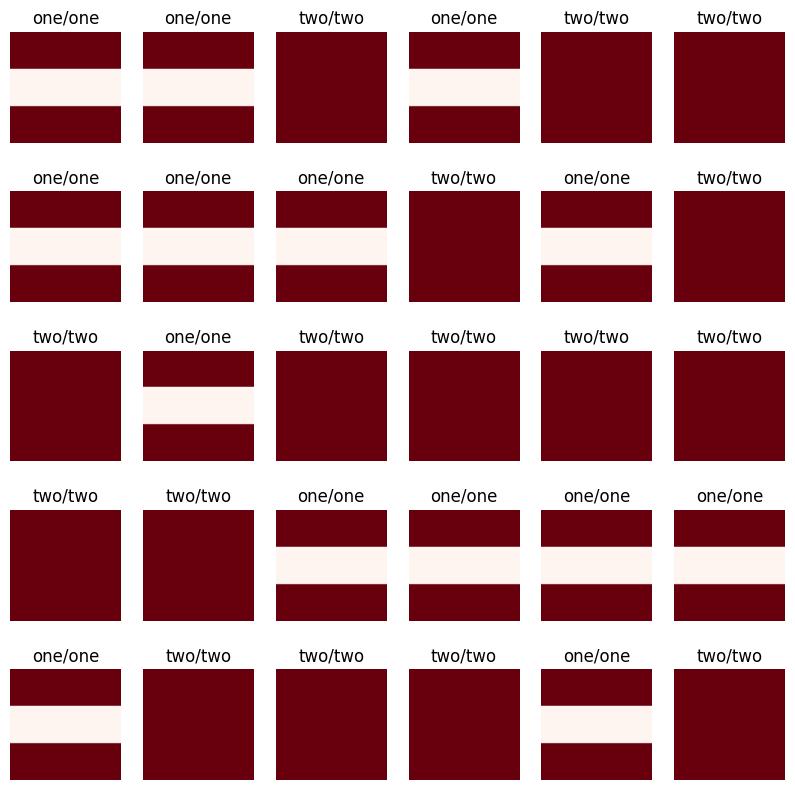

In [ ]:
# Test 데이터에서 image를 batch만큼 batch로 예측을 해 보면, (눈으로 확인해 보려구요)
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

# 예측과 Label결과물을 좀 살펴보고,
print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

# 눈으로 확인해 보자구요. (예측/레이블 순서로 표시)
plt.figure(figsize=(10, 10))
for i in range(30):
  ax = plt.subplot(5, 6, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]] + "/" + class_names[label_batch[i]])
  plt.axis("off")

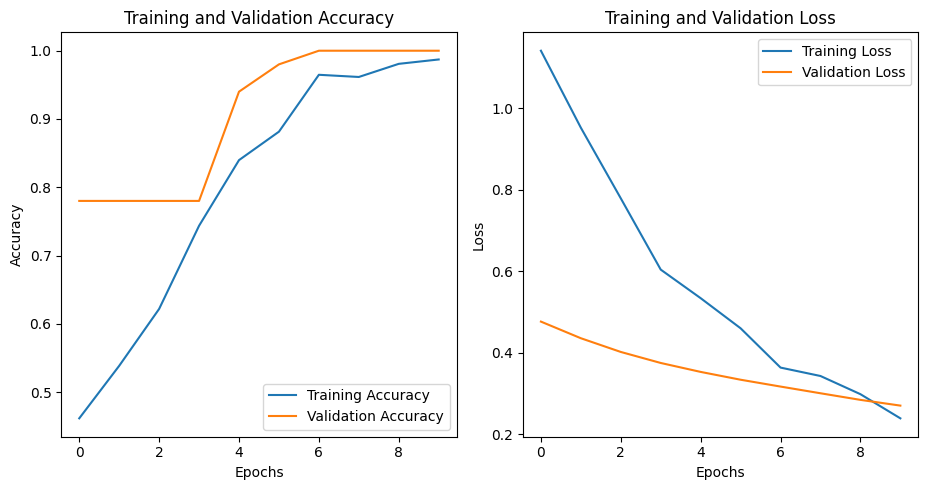

In [ ]:
import matplotlib.pyplot as plt

# history 객체에서 데이터 추출
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# AUC도 추적했다면 아래 코드 사용
auc = history.history.get('auc', None)  # 'auc'를 올바른 키로 교체해야 할 수 있음
val_auc = history.history.get('val_auc', None)

# 정확도와 손실을 위한 그래프 생성
plt.figure(figsize=(14, 5))

# 정확도 그래프 그리기
plt.subplot(1, 3, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실 그래프 그리기
plt.subplot(1, 3, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# AUC 그래프가 필요하다면 추가 그래프 생성
if auc and val_auc:
    plt.subplot(1, 3, 3)
    plt.plot(auc, label='Training AUC')
    plt.plot(val_auc, label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()

plt.tight_layout()
plt.show()


모델 저장 및 tflite변환

In [ ]:
model.save('./saved_mobilenetv2/')

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_mobilenetv2')
tflite_model = converter.convert()
open("converted_model.tflite", "wb").write(tflite_model)

8870268

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_mobilenetv2')
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()
open("converted_modelquantized.tflite", "wb").write(tflite_quantized_model)

2508576